In [1]:
from Diff import *
from solvers import *
from graph_init import *

In [3]:
def ed_diff_function(y, n, A, sizes, x0):
  '''
  This function takes a diffusion parameter y and returns the solution to the ED diffusion equation
  at the 2nd node (the specific node does not matter, it can be changed) and at time T.
  Here, we take the solution at the last iterated time step.
  '''

  y = (y+1)/2 # transformation on y to take it from [-1,1] to [0,1]
  c_bar = construct_cbar(y)

  C = construct_C(c_bar, sizes, n)
  D = construct_D(A, C, n)
  M = C*A - D
  
  # print(f'M is of shape {M.shape}')


  diff = ed_diffusion(M, x0, 0.1, T=1)
  return diff

In [4]:
from visualization import plot_diffusion

In [5]:
conf_vars = initialize_SBM(2, 5)
G, n, A, L, sizes, x0 = conf_vars


In [9]:
diff = ed_diff_function(np.array([0.6,0.7,0.7]), n, A, sizes, x0)

In [16]:
y = np.random.uniform(-1, 1, size=(10, 3))
for sample in y:
  diff = ed_diff_function(sample, n, A, sizes, x0)
  print(diff[2,-1])

32.63414002304103
20.61244060791244
20.931509880141864
26.57524169150273
21.663259454404486
21.135192416195633
29.040520617567047
28.904855693745414
42.18358673799167
27.35193636668265


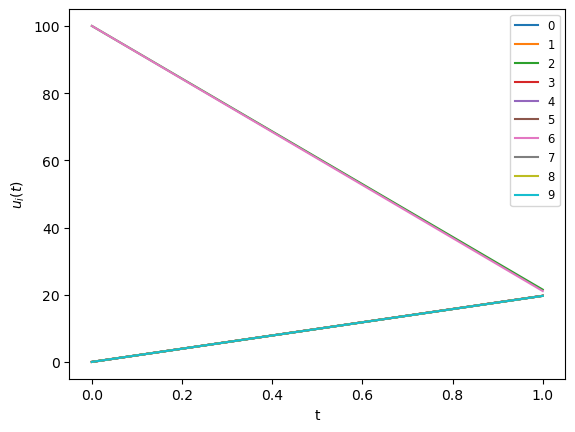

In [10]:
plot_diffusion(diff, range(diff.shape[0]))

In [11]:
diff[:,-1]

array([19.6923726 , 19.68364557, 21.51520946, 19.6923726 , 19.68364557,
       19.66420005, 21.09062344, 19.65686532, 19.66420005, 19.65686532])